## Modelling

It is now time to actually build our first models. We are going to try roughly three different types of model: linear regression, xgboost (will be referred to as our non linear model) and linear regression with boosted residuals (so xgboost fitted to the residuals of the linear regression, this will be referred to as the hybrid model). 

We are going to use the feature we found from 3_EDA_JFK. To model the seasonality, we are going to use fourier features (sin and cosine curves with the correct period at different harmonics passed as features). So this will mean weekly and yearly fourier features for the daily time series along with the significant daily lags we found according to autocorrelation. Similarly for the hourly series this will be daily and weekly fourier features and the significant hourly lags we found. However due to computational constraints we won't be able to use all of the hourly lags as there are just simply too many for my machine (note in hindsight it may have been worth using AWS for access to more computational resources to do the modelling). Instead we will take the first 336 significant hourly lags along with some additional hourly lags that we suspect may or may not be significant, these will be at around 180 days and 365 days (so 4320 hours and 8760 hours respectively). You can see this all within config/config.yml under the modelling key. 

Again we will make extensive use of helper functions from src/jfk_taxis to do lots of the heavy lifting behind the scenes. If you are interested in how the feature matrix is setup up then it may be worth looking at preprocess from the forecast_helpers.py module inside jfk_taxis. 

We are going to measure model performance using Mean Average Error (MAE) as this is a reasonably interpretable metric for our problem, i.e. an MAE of 200 means that on average the model predicted 200 more or less taxi pick ups than the true value. We will split the time series into training and test data, the boundary for this will be 2024-01-01 04:00:00+00:00 (4 AM because of UTC to NYC time conversions). This is a roughly 90:10 split, so we train on 90% of the data and test on 10%. To test on the test set we will use multistep forecasts, for the daily series these will be 7, 30 and 60 steps (so a week forecast, a month and two months). For the hourly series these will be 24, 168, 720 steps (so 1 day, 1 week and 1 month). These are multi step forecasts meaning the modelling can only predict using data from the start of its forecast, so the lags used for further predictions are generated using the models own predictions (this is called recursive forecasting). So that we sample a majority of the test set we will use a series of offsets to start our forecasts from, these are generated to ensure the forecasts cover most of the test set with some degree of random jitter so that they don't all fall on the same time of day or day of the week etc. You can see the offsets inisde config/config.yml under the modelling key as well as the code to generate them inside the modelling_helpers.py module (namely the make_offsets and make_offsets_from_series functions). For each of the three steps for the time series (so 7, 30, 60 for daily and 24, 168, 720 for hourly) we take the average of the MAEs across all the forecasts, to get some idea as to the models overall performance on the test set. To make the output in the notebooks readable we only show the plots to one offset in the variable offset_to_show, you can change this manually in the config file oir just by passing a list of the offsets you would like to display. There is also a bar chart of the MAE for each model for each forecast, as well as bar charts showing the models average MAE across all offsets for each of the forecast steps.

We are going to need to compare our models to some sort of naive baseline so that we can tell whether or not they are actually extracting predictive power from the features, or are no better than simple non machine learning methods. Our naive baseline will be to predict the current value to be the same as the value one time step ago, so one hour or one day. I originally experimented with several naive baselines and this seemed to perform the best. We will later comment in the 5_model_selection notebook that a majority of models will rank lag_1 as their most important feature by average SHAP value. Which does suggest that just one time step ago is a good naive predictor for the current number of taxi pick ups. 

In [1]:
from jfk_taxis import run_forecasts, create_train_save_models, load_config, load_models, load_process_lags, load_ts_data, split_test_train_sets, make_offsets_from_series, save_config
from xgboost import XGBRegressor

In [2]:
# Load the config and the project root
config, PROJECT_ROOT = load_config()


In [3]:
# First load the significant lags
daily_lags, used_hourly_lags = load_process_lags()

In [4]:
# Load ts data
ts_daily, ts_hourly = load_ts_data()

In [5]:
# Create test train sets as defined in config.yml
ts_daily_train, ts_daily_test, ts_hourly_train, ts_hourly_test = split_test_train_sets(ts_daily, ts_hourly)

In [6]:
# We now need to create a list of offsets for when we want to forecast (i.e. the starting points for each forecast)

daily_offsets = make_offsets_from_series(ts_daily_test, config["modelling"]["daily_offset_size"], config["modelling"]["daily_steps"])

hourly_offsets = make_offsets_from_series(ts_hourly_test, config["modelling"]["hourly_offset_size"], config["modelling"]["hourly_steps"])

In [7]:
# Save the offsets to the config, note we have set the random state when generating the offsets so will be reproducible

config["modelling"]["daily_offset"] = daily_offsets
config["modelling"]["hourly_offset"] = hourly_offsets

config, PROJECT_ROOT = save_config(config)

In [8]:
# As there are 19 offsets it would be good to only plot a smaller subset of these for readability. 
# You can change which ones you want here, the defualts will be just the first offset
daily_offsets_to_show = [daily_offsets[0]]
hourly_offsets_to_show = [hourly_offsets[0]]

# Save these to config
config["modelling"]["daily_offsets_to_show"] = daily_offsets_to_show
config["modelling"]["hourly_offsets_to_show"] = hourly_offsets_to_show

config, PROJECT_ROOT = save_config(config)

In [9]:
# Create models and forecasts for daily ts

# 181 days in 2025 in the data, meaning 546 is the max number of steps we can forecast

# Steps for the forecast (read config.yml to see and change the steps for the forecast)
steps = config["modelling"]["daily_steps"]

# Offset to start the forecast from in the test values (value of zero means start at the begining, value of 1 means start at the second value etc)
offset_list = config["modelling"]["daily_offset"]

# List of offsets to show the forecasts for (can change few cells above)
offset_to_show = config["modelling"]["daily_offsets_to_show"]

# Fourier features (yearly and weekly)
fourier_features = config["modelling"]["daily_fourier_features"]

# List of trend orders for our linear models 
order_list = config["modelling"]["daily_linear_trends"]

# Hybrid, the hybrid model we will be using
hybrid = None

# Time step of the series
time_step = "D"

# Time series to use for training
ts_train = ts_daily_train

# Time series to use for testing
ts_test = ts_daily_test

# Lags for training
lags = daily_lags

# Linear name list (list of names for the linear models)
names_linear = [f"{config['model_naming']['linear_model_prefix']}{i}" for i in order_list]

# Non linear name list 
names_non_linear = [config["model_naming"]["default_non_linear"]]

# Signature for the file names (this will be how we keep track of which files belong to which models when it comes to hyperparamter tuning)
sig = config["model_sigs"]["daily_linear"]

# Naive baseline (bool to determine whether or not to inlcude a naive baseline in the plots, the naive baseline will just predict time step value t as time step value t-1)
naive = True



In [10]:
# We now create the design matrix for the model with the above parameters
# We fit the models and we save them into .pkl objects as dictionaries
# We will then load the models for the forecasts (please read jfk_taxis/modelling_helpers.py for more info if needed)
create_train_save_models(names_linear, names_non_linear, hybrid, sig, order_list, lags, fourier_features, time_step, ts_train)

In [11]:
# Load the models (and the deterministic processes)
linear_models_loaded, non_linear_models_loaded = load_models(sig)

MAE: 361.28 for step = 7, model = linear_order0
MAE: 372.00 for step = 7, model = linear_order1
MAE: 365.42 for step = 7, model = linear_order2
MAE: 351.26 for step = 7, model = linear_order3
MAE: 378.59 for step = 7, model = linear_order4
MAE: 7434.61 for step = 7, model = linear_order5
MAE: 321.99 for step = 7, model = base_non_linear
MAE: 621.71 for step =  30, model = Naive



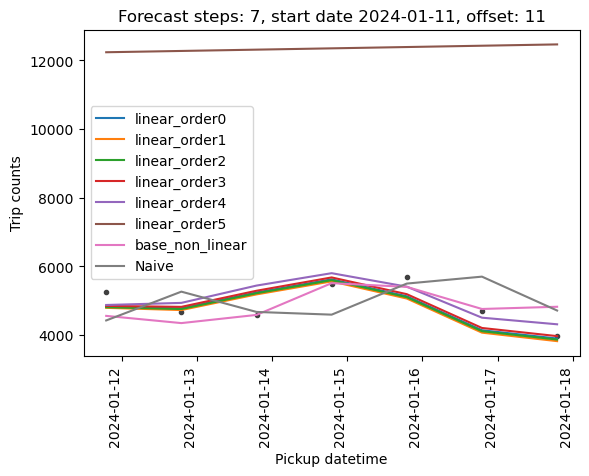

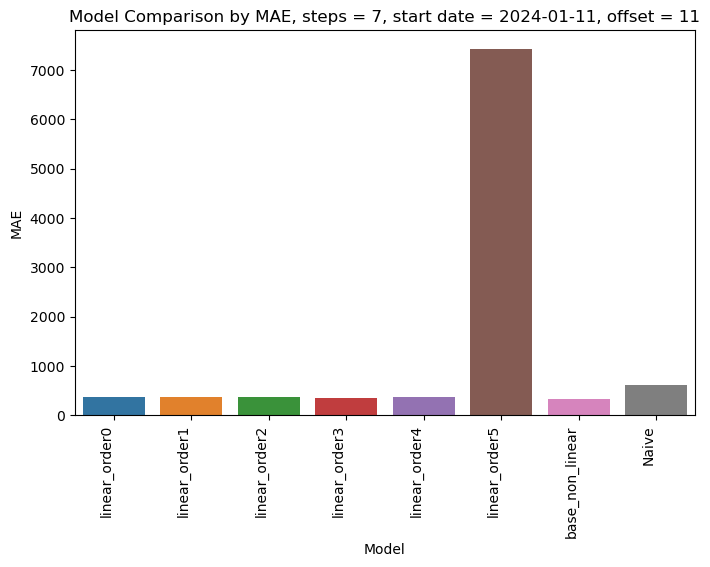

MAE: 294.52 for step = 30, model = linear_order0
MAE: 323.09 for step = 30, model = linear_order1
MAE: 304.11 for step = 30, model = linear_order2
MAE: 305.40 for step = 30, model = linear_order3
MAE: 787.91 for step = 30, model = linear_order4
MAE: 8518.45 for step = 30, model = linear_order5
MAE: 844.57 for step = 30, model = base_non_linear
MAE: 637.10 for step =  30, model = Naive



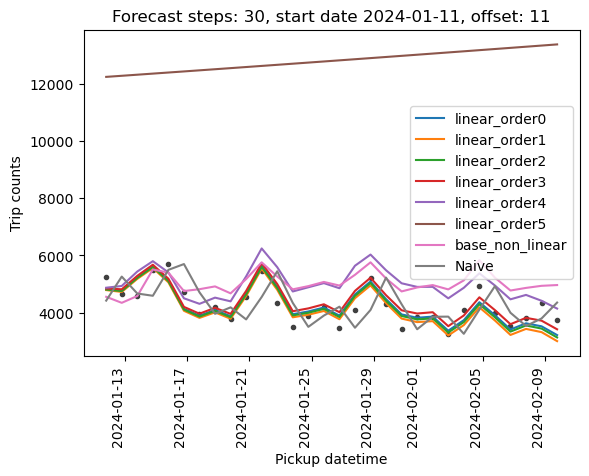

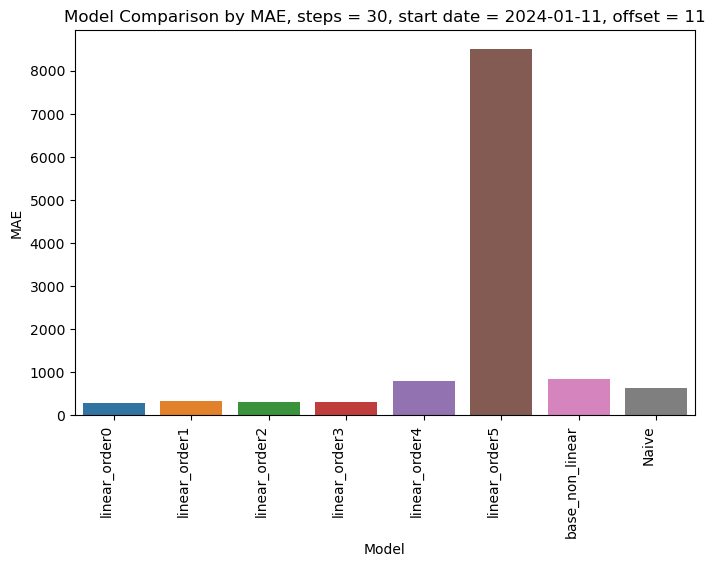

MAE: 329.40 for step = 60, model = linear_order0
MAE: 362.53 for step = 60, model = linear_order1
MAE: 331.46 for step = 60, model = linear_order2
MAE: 398.95 for step = 60, model = linear_order3
MAE: 700.82 for step = 60, model = linear_order4
MAE: 8913.28 for step = 60, model = linear_order5
MAE: 805.95 for step = 60, model = base_non_linear
MAE: 607.33 for step =  30, model = Naive



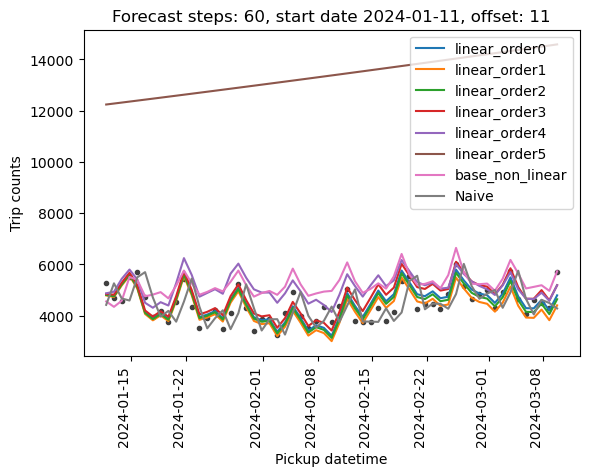

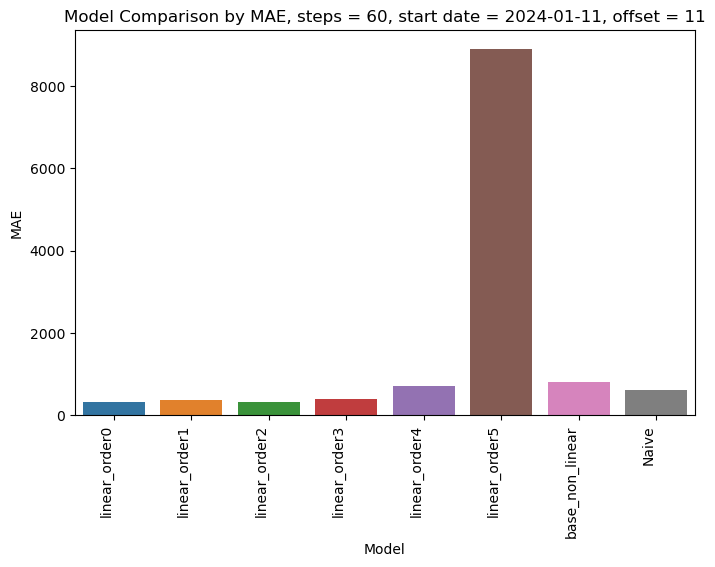


Average MAE scores for step 60:
linear_order0, average MAE: 471.01
linear_order3, average MAE: 649.23
linear_order2, average MAE: 470.28
linear_order1, average MAE: 508.87
linear_order4, average MAE: 689.39
linear_order5, average MAE: 21146.02
base_non_linear, average MAE: 508.50
Naive, average MAE: 640.27

Average MAE scores for step 30:
linear_order0, average MAE: 418.62
linear_order3, average MAE: 507.44
linear_order2, average MAE: 415.41
linear_order1, average MAE: 420.86
linear_order4, average MAE: 545.71
linear_order5, average MAE: 20245.98
base_non_linear, average MAE: 475.96
Naive, average MAE: 630.26

Average MAE scores for step 7:
linear_order0, average MAE: 421.41
linear_order3, average MAE: 446.88
linear_order2, average MAE: 421.30
linear_order1, average MAE: 420.50
linear_order4, average MAE: 448.46
linear_order5, average MAE: 19622.55
base_non_linear, average MAE: 394.24
Naive, average MAE: 602.31


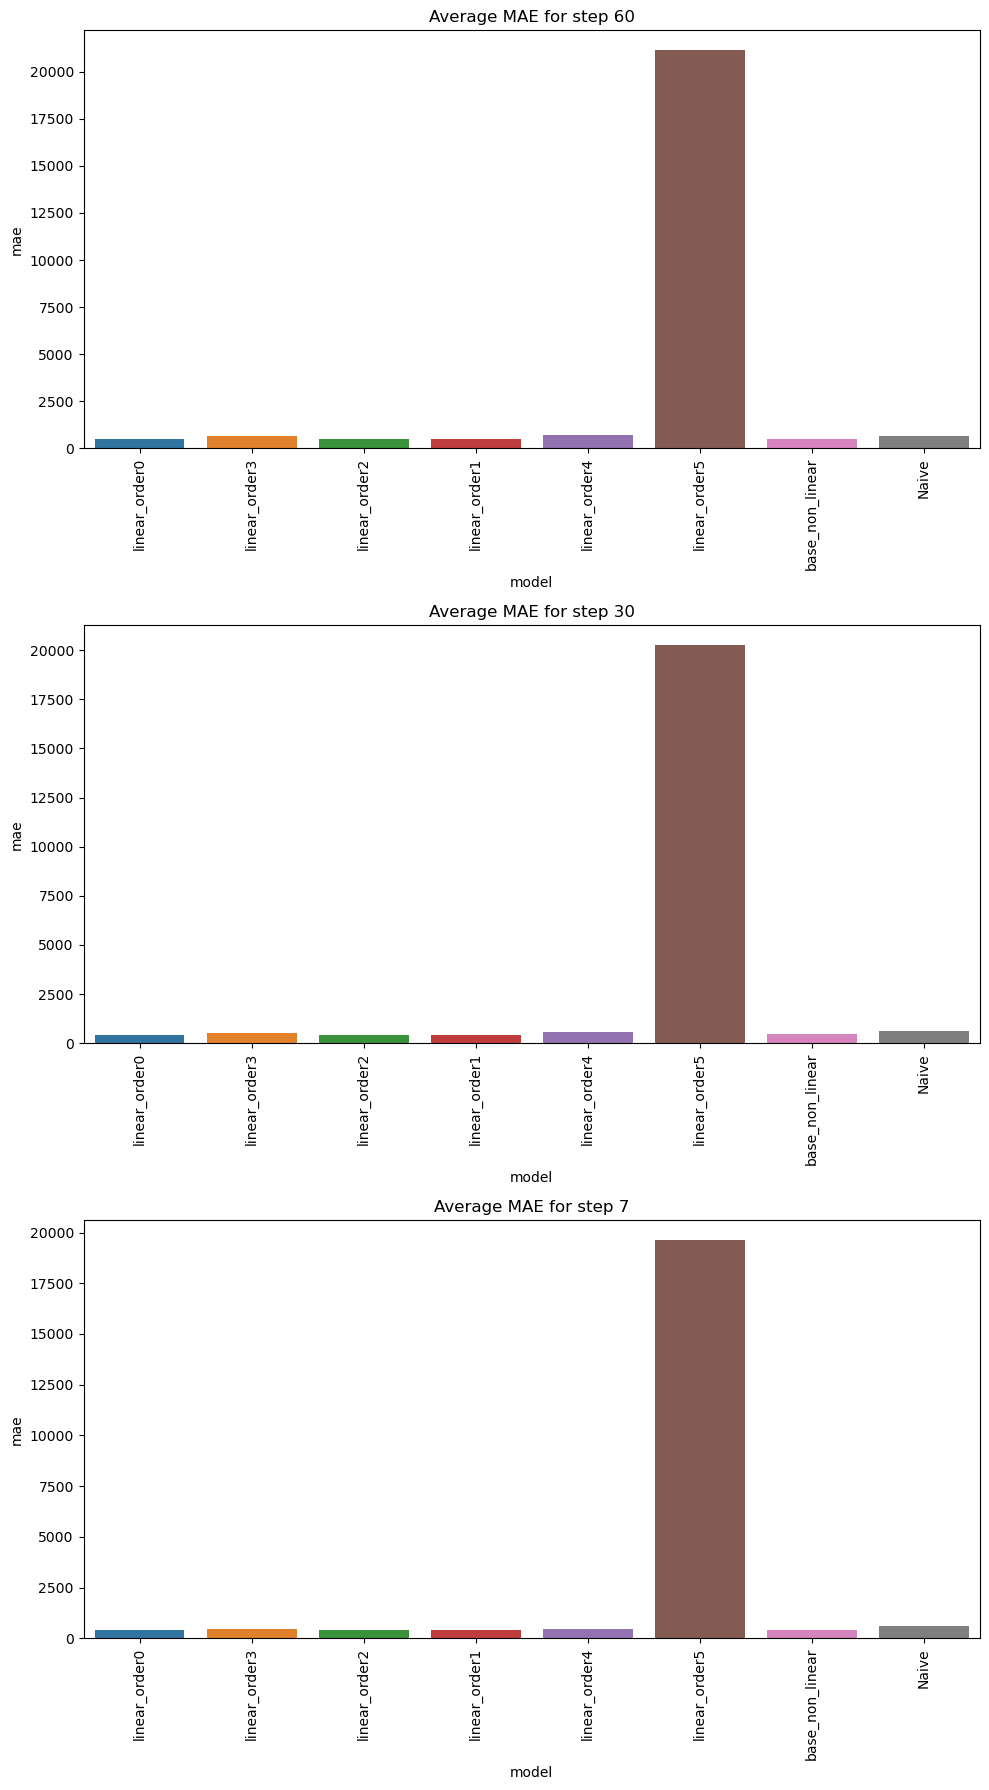

In [12]:
# Run forecasts
run_forecasts(steps, offset_list, offset_to_show, linear_models_loaded, non_linear_models_loaded, naive, time_step, ts_train, ts_test)

In the above linear_orderX is a linear model on constant + trend + lags with weekly and yearly fourier features, where X is the order of the trend (0 non trend, 1 linear, 2 quadratic etc). Base_non_linear is just XGBoost on weekly and yearly fourier features + lags. Naive is just a lag of 1, so it estimates that the current taxi count is yesterdays taxi count. 

The first obvious thing to note is that linear_order5 has a much higher MAE than the others, this is likely due to having too high of a degree on the polynomial trend so that the model no longer makes sensible predictions by the time we use it to forecast. It is interesting although not sure here during my inital exploration of modelling you could see very clearly that with higher order polynomials if you created say a yearly multi step forecast, over time they would move further and further away from the true data likely due to the large values of their polynomial trend.

We see that for the 7 day forecast base_non_linear performs on average the best with an MAE of 394.24 over the offsets, linear_order1 in second place with 420.50 MAE and linear_order0 in third with 421.41 MAE. The Naive baseline has an average MAE of 602.31 so we have already made a 34.5% improvement compared to baseline. It is worth making a brief remark on the scale we are working in as well. If you look at the time series plots in 2_data_processing you will see that it appears that since 2024 taxi pick ups and JFK airport lie roughly between 3,000 and 8,000. So an MAE of around 400 is at worst around a 13.3% absolute error. 

For the 30 day forecast now linear_order2 has the lowest average MAE of 415.41 followed by linear_order0 with 418.62 followed by linear_order1 with 420.86. Naive baseline has an average MAE of 630.26 so this is at best a 34.1% improvement on baseline. It is interesting to note that at the larger forecast steps base_non_linear (so xgboost) performs worse than the linear regressions. One reason for this is perhaps because the linear regressions can better capture more general long term trends within the data than perhaps xgboost can which is a tree based machine learning method. You can see this in the forecasts themsevles where for a step of 30 base_non_linear is clearly consitently predicting above the general trend of the data, and is not following the general trend as well as other models like linear_order0. Another potential cause may have been COVID, my inital guess was that linear_order2 would be one of the best models at least for the daily time series, because if you look at the say 365 day rolling averages they look almost quadratic in shape (so the COVID dip forms a minima and we increase after COVID consitently and decrease before COVID consitently). Certainly, during my experimentations on more long term 365 day forecasts it appeared that linear_order2 was one of the best linear regression models to use, although unfortunately we do not discuss that here. 

Now for the 60 day forecast we now have linear_order2 with the lowest average MAE of 470.28, linear_order0 with an average MAE of 471.01 and base_non_linear in third with an average MAE of 508.50. The Naive baseline has an average MAE of 640.27 so we have made a roughly 26.5% improvement on baseline. 

So from here we conclude that base_non_linear appears to be the best model for the 7 day forecast, linear_order2 for the 30 and 60 day forecasts. Although it's worth noting there isn't a lot of difference in MAE between linear_order0 and linear_order2 for the 30 and 60 day forecasts.

We are now going to try fitting the hybrid models to the daily time series. The hybrid models are simple a linear regression like linear_order2 but with xgboost fitted onto the residuals of the linear regression. Then a new prediction is the sum of the linear regression component + the xgboost component. The idea being that the linear regression can capture the more general sweeping trends in say yearly seasonality more easily than xgboost. But xgboost can capture more fine tuned patterns by splitting on any of the 336 lags we are using. As we have already established that polynomial trends over 4 don't appear to be useful we will just go up to 3 in the hybrid model (we have gone up to 3 and not just 2 even though linear_order3 didn't perform within the top 3, but more to double check that higher order trends don't suddenly become better when we start using hybrid models).

In [30]:
# Create models and forecasts for daily ts

# 181 days in 2025 in the data, meaning 546 is the max number of steps we can forecast

# Steps for the forecast (read config.yml to see and change the steps for the forecast)
steps = config["modelling"]["daily_steps"]

# Offest
offset_list = config["modelling"]["daily_offset"]

# List of offsets to show the forecasts for
offset_to_show = config["modelling"]["daily_offsets_to_show"]

# Fourier features (yearly and weekly)
fourier_features = config["modelling"]["daily_fourier_features"]

# List of trend orders for our linear models 
order_list = config["modelling"]["daily_hybrid_trends"]

# Hybrid, the hybrid model we will be using
hybrid = XGBRegressor(
        n_estimators=config["xgboost_default"]["n_estimators"],
        learning_rate=config["xgboost_default"]["learning_rate"],
        max_depth=config["xgboost_default"]["max_depth"],
        subsample=config["xgboost_default"]["subsample"],
        colsample_bytree=config["xgboost_default"]["colsample_bytree"],
        random_state=config["xgboost_setup"]["random_state"],
        eval_metric=config["xgboost_setup"]["eval_metric"],
        tree_method=config["xgboost_setup"]["tree_method"],
        device=config["xgboost_setup"]["device"]
)

# Time step of the series
time_step = "D"

# Time series to use for training
ts_train = ts_daily_train

# Time series to use for testing
ts_test = ts_daily_test

# Lags for training
lags = daily_lags

# Linear name list (list of names for the linear models)
names_linear = [f"{config['model_naming']['hybrid_model_prefix']}{i}" for i in order_list]

# Non linear name list 
names_non_linear = [config["model_naming"]["default_non_linear"]]

# Signature for the file names (this will be how we keep track of which files belong to which models when it comes to hyperparamter tuning)
sig = config["model_sigs"]["daily_hybrid"]

# Naive baseline (bool to determine whether or not to inlcude a naive baseline in the plots, the naive baseline will just predict time step value t as time step value t-1)
naive = True



In [31]:
# Create train and save the models
create_train_save_models(names_linear, names_non_linear, hybrid, sig, order_list, lags, fourier_features, time_step, ts_train)

In [32]:
# Load the models (and the deterministic processes)
hybrid_models_loaded, non_linear_models_loaded = load_models(sig)

MAE: 356.62 for step = 7, model = hybrid_order0
MAE: 384.29 for step = 7, model = hybrid_order1
MAE: 384.87 for step = 7, model = hybrid_order2
MAE: 407.92 for step = 7, model = hybrid_order3
MAE: 321.99 for step = 7, model = base_non_linear
MAE: 621.71 for step =  30, model = Naive



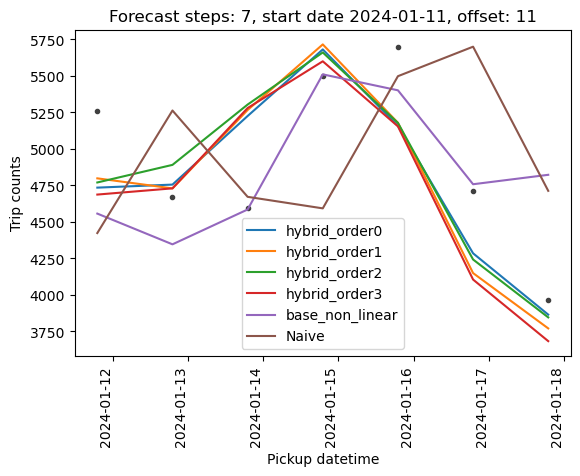

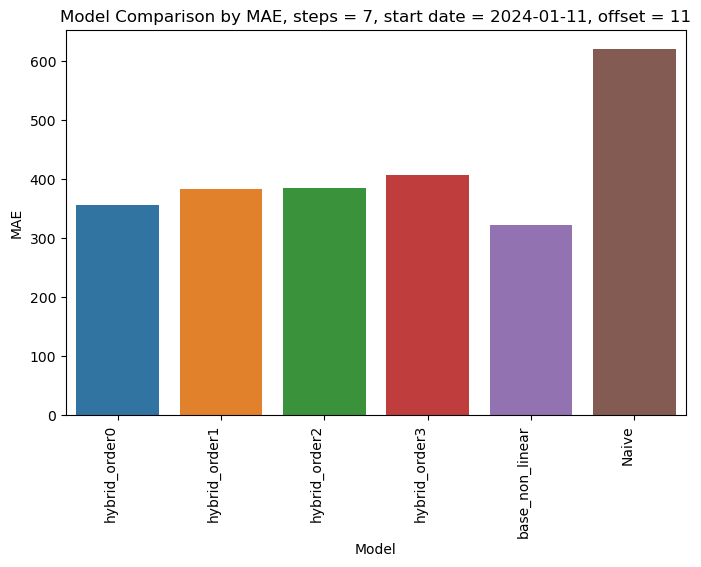

MAE: 301.72 for step = 30, model = hybrid_order0
MAE: 284.74 for step = 30, model = hybrid_order1
MAE: 297.52 for step = 30, model = hybrid_order2
MAE: 294.29 for step = 30, model = hybrid_order3
MAE: 844.57 for step = 30, model = base_non_linear
MAE: 637.10 for step =  30, model = Naive



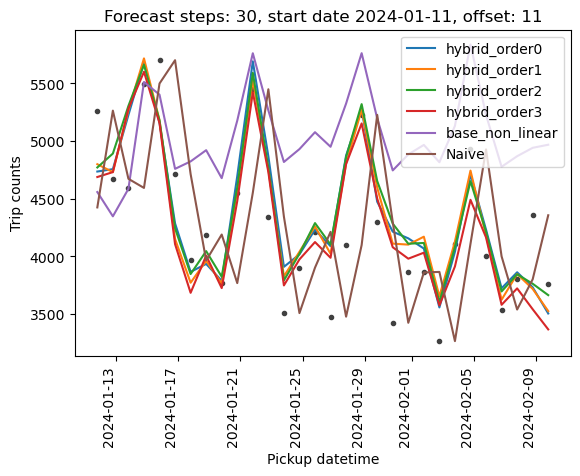

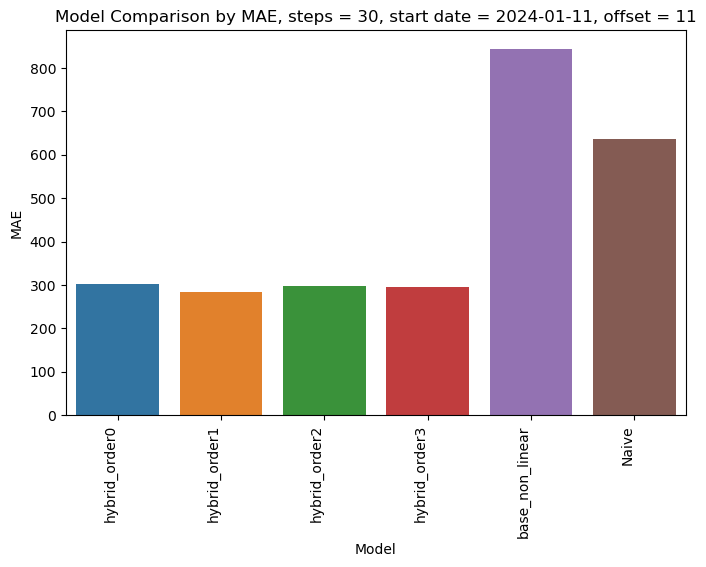

MAE: 399.69 for step = 60, model = hybrid_order0
MAE: 324.40 for step = 60, model = hybrid_order1
MAE: 354.97 for step = 60, model = hybrid_order2
MAE: 327.82 for step = 60, model = hybrid_order3
MAE: 805.95 for step = 60, model = base_non_linear
MAE: 607.33 for step =  30, model = Naive



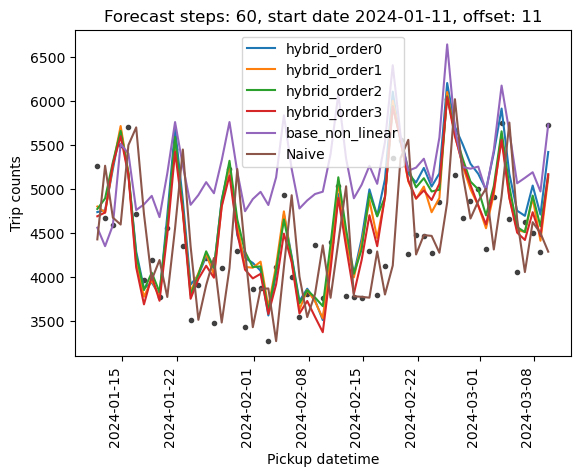

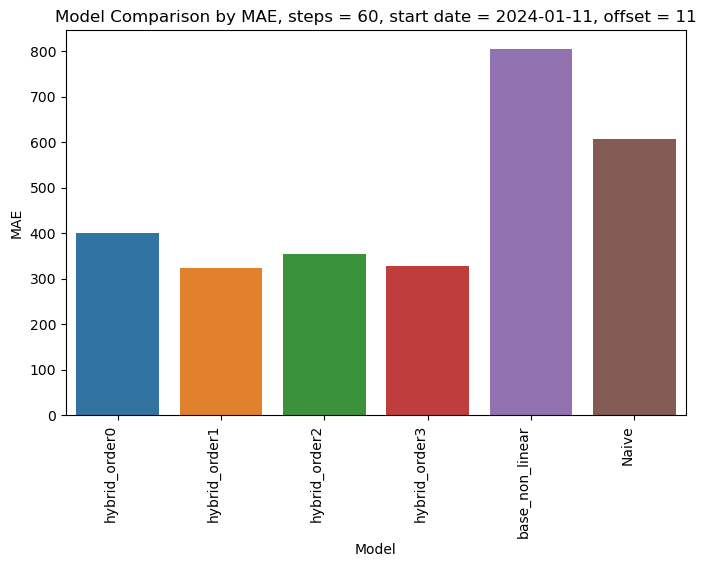


Average MAE scores for step 60:
hybrid_order2, average MAE: 526.40
hybrid_order1, average MAE: 537.62
hybrid_order0, average MAE: 482.23
base_non_linear, average MAE: 508.50
hybrid_order3, average MAE: 563.80
Naive, average MAE: 640.27

Average MAE scores for step 30:
hybrid_order2, average MAE: 444.43
hybrid_order1, average MAE: 451.28
hybrid_order0, average MAE: 420.74
base_non_linear, average MAE: 475.96
hybrid_order3, average MAE: 477.07
Naive, average MAE: 630.26

Average MAE scores for step 7:
hybrid_order2, average MAE: 465.37
hybrid_order1, average MAE: 494.93
hybrid_order0, average MAE: 436.51
base_non_linear, average MAE: 394.24
hybrid_order3, average MAE: 496.31
Naive, average MAE: 602.31


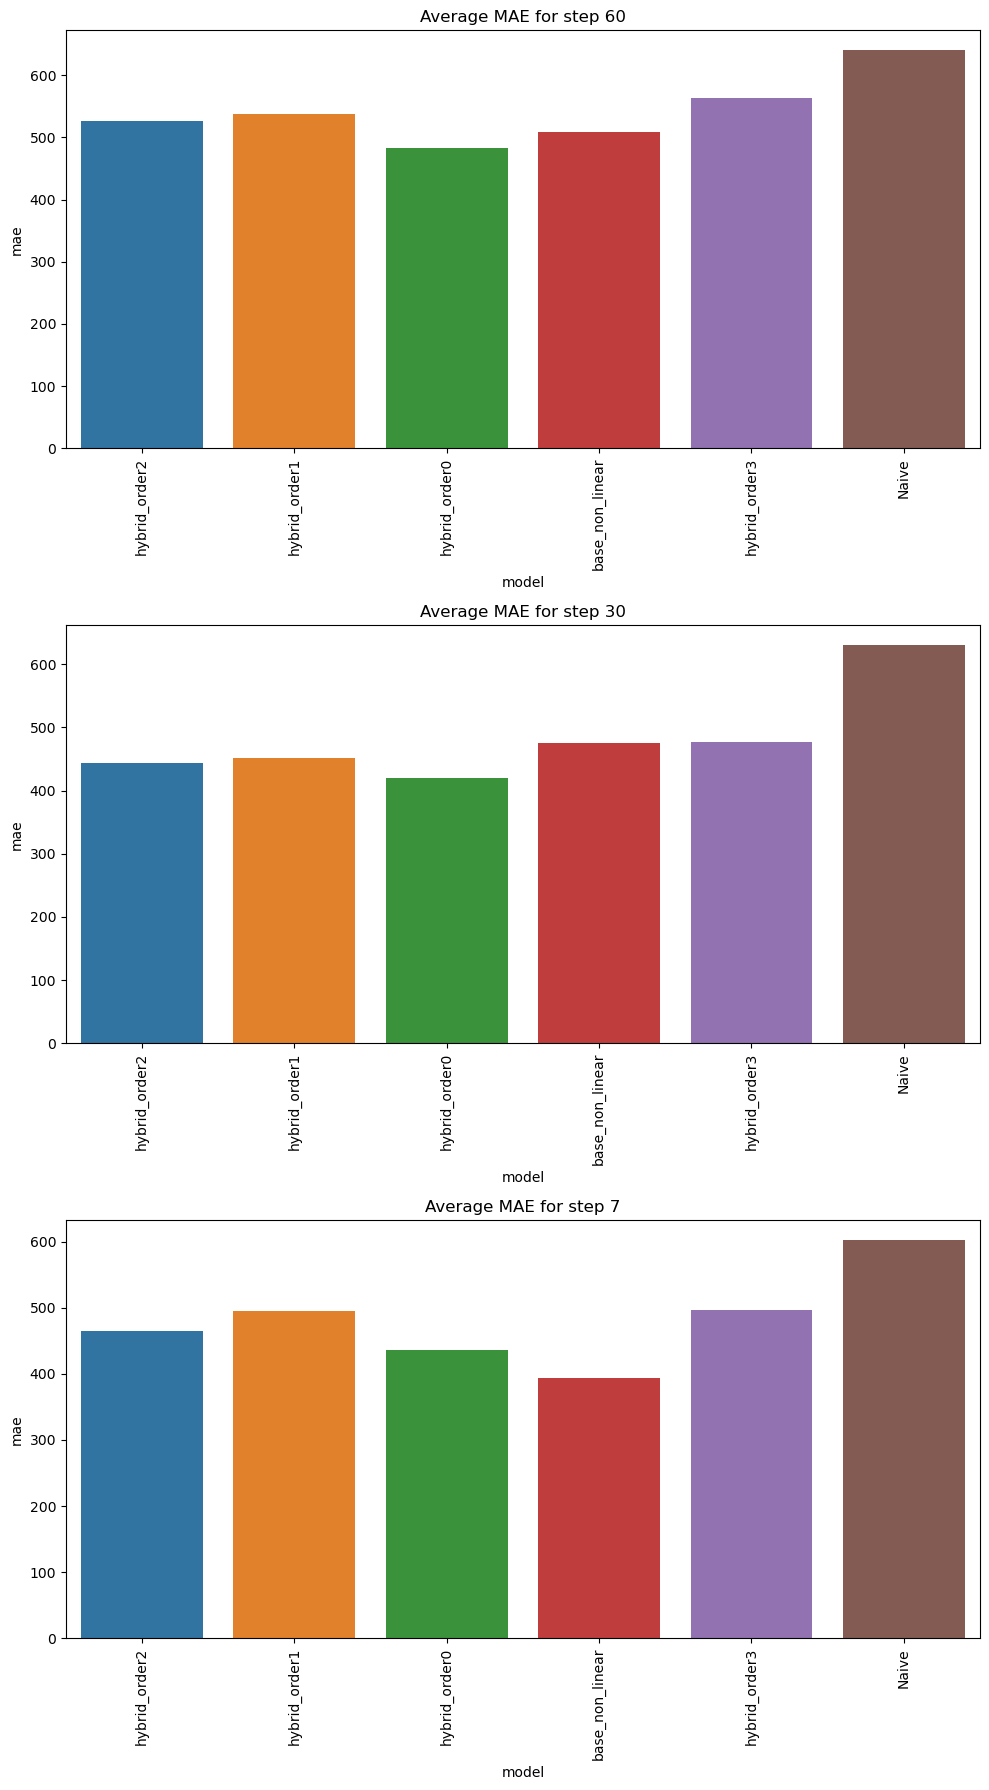

In [33]:
# Run forecasts
run_forecasts(steps, offset_list, offset_to_show, hybrid_models_loaded, non_linear_models_loaded, naive, time_step, ts_train, ts_test)

Looking at the 7 day forecast we have that base_non_linear has the lowest average MAE of 394.24, followed by hybrid_order0 with 436.51 and then hybrid_order2 with 465.37. The naive baseline has an average MAE of 602.31 so we have made at best a 34.5% improvement on baseline. This is no change from the purely linear case where base_non_linear was also the best model by average MAE across the offsets.

Looking at the 30 day forecast we have that hybrid_order0 has the lowest average MAE of 420.74, followed by hyrid_order2 with 444.43 and then hybrid_order1 with 451.28. The naive baseline has an average MAE of 630.26 so we have made at a 33.2% improvement on baseline. Interestingly in the purely linear case for the 30 day forecast linear_order2 actually has a lower average MAE of 415.41 as does linear_order0 with 418.62. So what we are seeing is that at least for the 30 day forecast it seems the hybrid models are actually slightly worse by a few MAE. 

Looking at the 60 day forecast we have that hybrid_order0 has the lowest average MAE of 482.23, followed by base_non_linear with 508.50 and then hybrid_order2 with 526.40. The naive baseline has an average MAE of 640.27. So we have made a 24.7% improvement on baseline. Again if we compare to the purely linear case we see that the hybrid models are again performing slightly worse by about 12 MAE. linear_order2 had the lowest average MAE of 470.28, followed by linear_order0 with 471.01.

Now this doesn't mean we should necessarily discard the hybrid models straight away. One of the problems we have at the moment is that we haven't tuned the hyperparamters of xgboost, instead we have just manually set some defaults. We are also using a fixed number for n_estimators not early stopping meaning we are potentially either overfitting or underfitting to the data. This will be addressed later when we perform Bayesian hyperparameter tuning so it's worth reserving intial judgements on hybrid vs linear for now as they are both very close in performance and potentially with some tuning the hybird models will actually be better. 

Another intersting thing to note is that in the hybrid case hybrid_order0 consitently outperforms hybrid_order2 whereas in the linear case this is flipped. Potentially part of the reason for this may be that the xgboost component of the hybrid model is having trees split on the trend. Which is perhaps not terribly helpful depending on how it is using that split, resulting in the no trend case (hybrid_order0) to perform slightly better. 

Just for interest so we can see them on the same graph we plot linear_order2 alongside the hybrid models just so we can see visually if they are doing anything different.

In [34]:
# Steps for the forecast
steps = config["modelling"]["daily_steps"] 

# Offset 
offset_list = config["modelling"]["daily_offset"]

# We won't include the naive model this time
naive = False

# Time step
time_step = "D"

# Time series to use for training
ts_train = ts_daily_train

# Time series to use for testing
ts_test = ts_daily_test

# Lags
lags = daily_lags

In [35]:
# Load models
linear_sig = config["model_sigs"]["daily_linear"]
hybrid_sig = config["model_sigs"]["daily_hybrid"]


linear_models_loaded, non_linear_models_loaded = load_models(linear_sig)
hybrid_models_loaded, non_linear_models_loaded = load_models(hybrid_sig)

In [36]:
# Pop linear_order2
lo2 = linear_models_loaded.pop("linear_order2")

# Insert linear_order0
hybrid_models_loaded["linear_order2"] = lo0

# Reset non_linear dict
non_linear_models_loaded = {}




MAE: 356.62 for step = 7, model = hybrid_order0
MAE: 384.29 for step = 7, model = hybrid_order1
MAE: 384.87 for step = 7, model = hybrid_order2
MAE: 407.92 for step = 7, model = hybrid_order3
MAE: 361.28 for step = 7, model = linear_order2


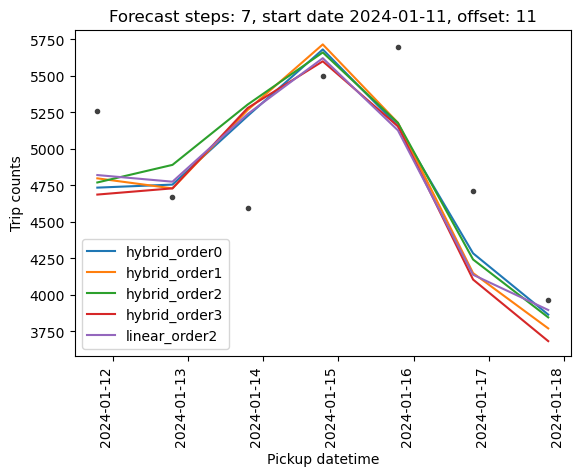

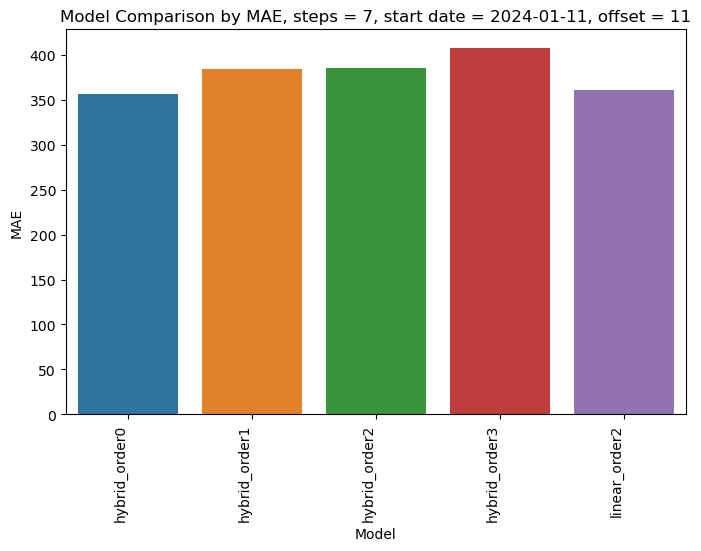

MAE: 301.72 for step = 30, model = hybrid_order0
MAE: 284.74 for step = 30, model = hybrid_order1
MAE: 297.52 for step = 30, model = hybrid_order2
MAE: 294.29 for step = 30, model = hybrid_order3
MAE: 294.52 for step = 30, model = linear_order2


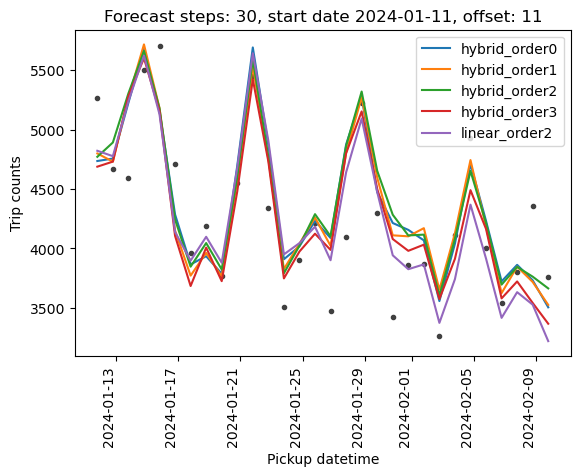

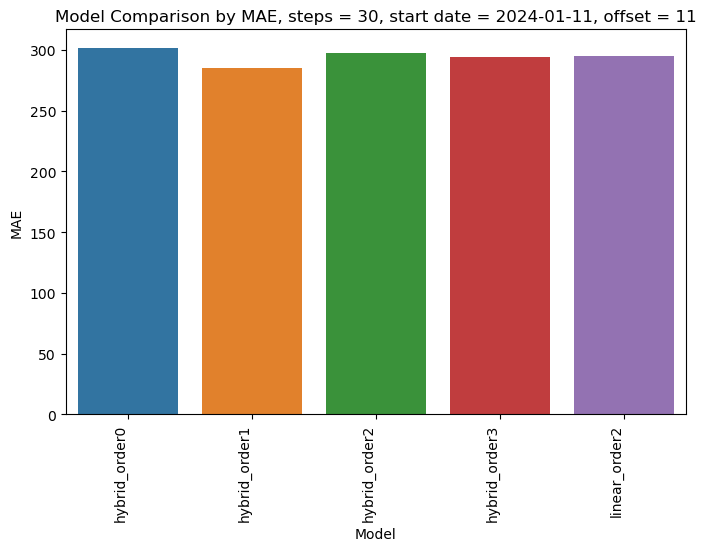

MAE: 399.69 for step = 60, model = hybrid_order0
MAE: 324.40 for step = 60, model = hybrid_order1
MAE: 354.97 for step = 60, model = hybrid_order2
MAE: 327.82 for step = 60, model = hybrid_order3
MAE: 329.40 for step = 60, model = linear_order2


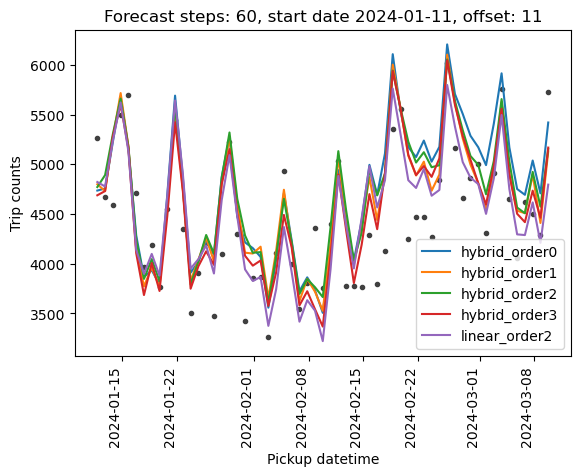

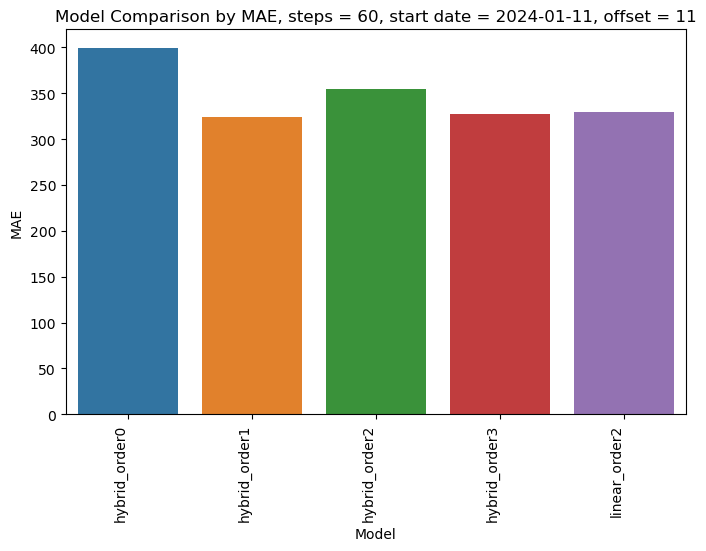


Average MAE scores for step 60:
linear_order2, average MAE: 471.01
hybrid_order2, average MAE: 526.40
hybrid_order1, average MAE: 537.62
hybrid_order0, average MAE: 482.23
hybrid_order3, average MAE: 563.80

Average MAE scores for step 30:
linear_order2, average MAE: 418.62
hybrid_order2, average MAE: 444.43
hybrid_order1, average MAE: 451.28
hybrid_order0, average MAE: 420.74
hybrid_order3, average MAE: 477.07

Average MAE scores for step 7:
linear_order2, average MAE: 421.41
hybrid_order2, average MAE: 465.37
hybrid_order1, average MAE: 494.93
hybrid_order0, average MAE: 436.51
hybrid_order3, average MAE: 496.31


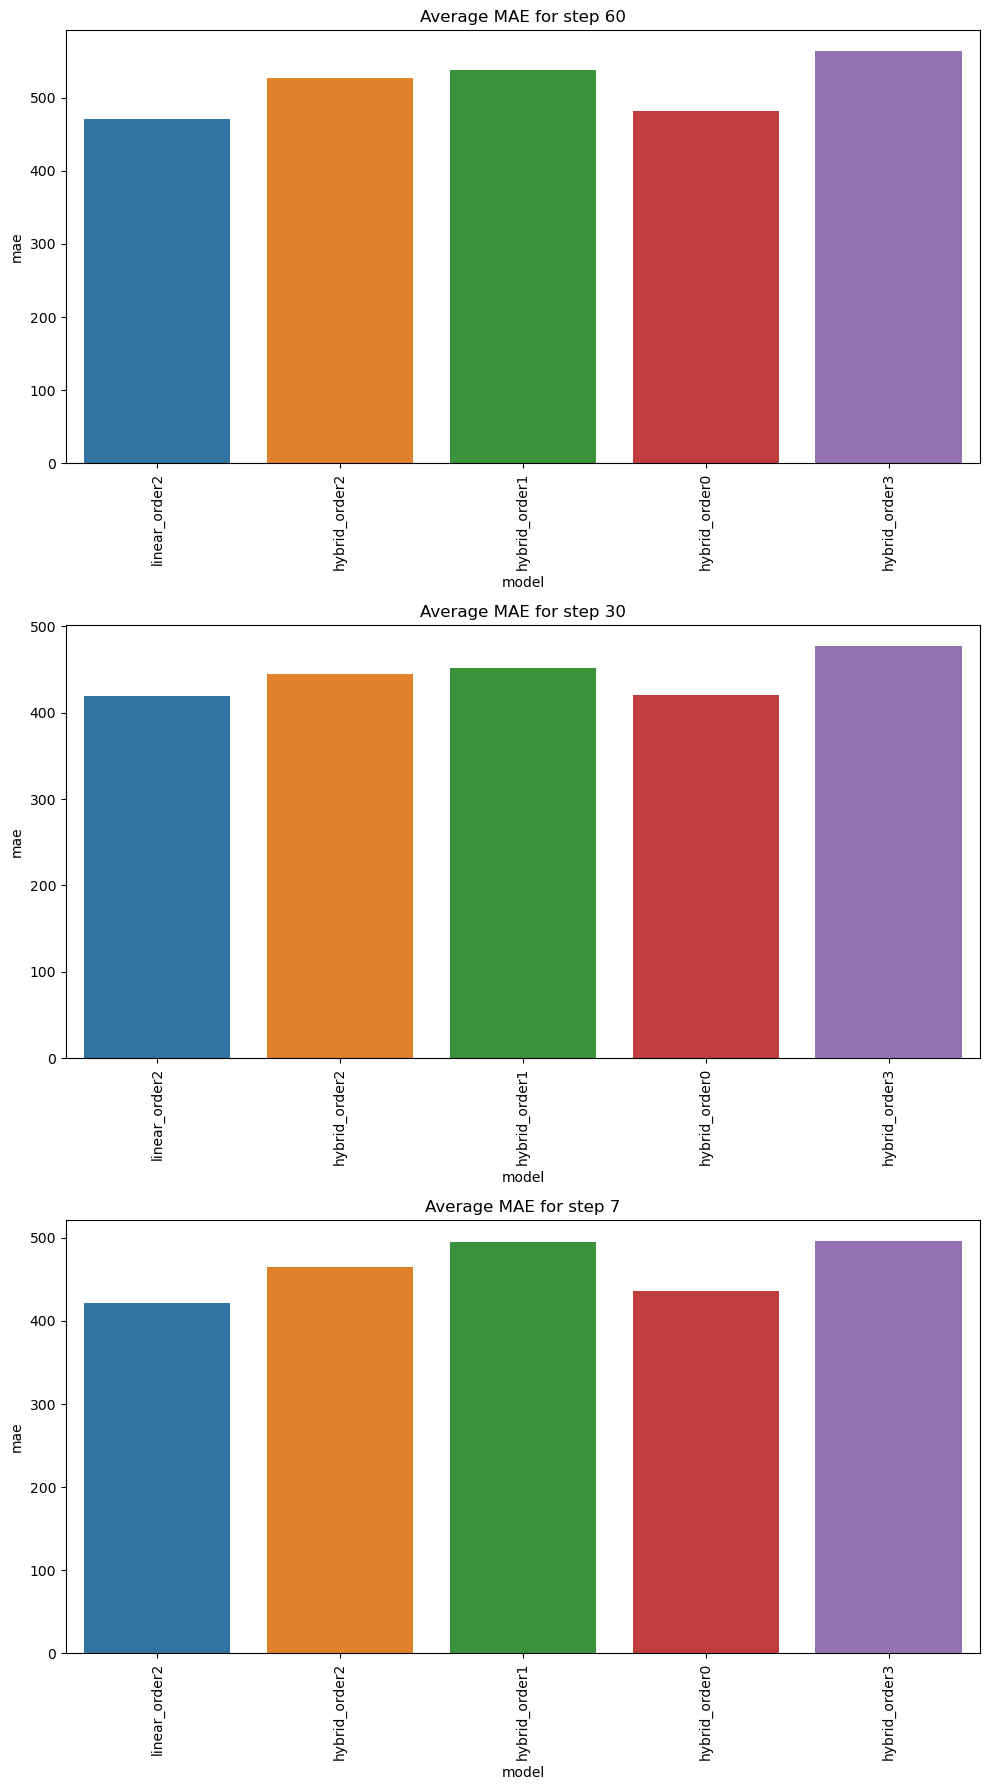

In [37]:

# Run forecasts, set Naive to False so we don't get a naive forecast
run_forecasts(steps, offset_list, offset_to_show, hybrid_models_loaded, non_linear_models_loaded, naive, time_step, ts_train, ts_test)

Just looking at the plots it is clear that our models are all incredibly similar, with perhaps the hybrid models having a slight bias to predict slightly higher than linear_order0 at least in the plots shown, but not by terribly much. Another reassuring sanity check for us is that the models do seem to be following the data reasonably well, at least for these forecast steps.

We are now going to repeat the same for the hourly time series.

In [38]:
# Create models and forecasts for daily ts

# 181 days in 2025 in the data, meaning 546 is the max number of steps we can forecast

# Steps for the forecast (read config.yml to see and change the steps for the forecast)
steps = config["modelling"]["hourly_steps"]

# Offset
offset_list = config["modelling"]["hourly_offset"]

# List of offsets to show the forecasts for
offset_to_show = config["modelling"]["hourly_offsets_to_show"]

# Fourier features (weekly and daily)
fourier_features = config["modelling"]["hourly_fourier_features"]

# List of trend orders for our linear models 
order_list = config["modelling"]["hourly_linear_trends"]

# Hybrid, the hybrid model we will be using
hybrid = None

# Time step of the series
time_step = "h"

# Time series to use for training
ts_train = ts_hourly_train

# Time series to use for testing
ts_test = ts_hourly_test

# Lags for training
lags = used_hourly_lags

# Linear name list (list of names for the linear models)
names_linear = [f"{config['model_naming']['linear_model_prefix']}{i}" for i in order_list]

# Non linear name list 
names_non_linear = [config["model_naming"]["default_non_linear"]]

# Signature for the file names (this will be how we keep track of which files belong to which models when it comes to hyperparamter tuning)
sig = config["model_sigs"]["hourly_linear"]

# Naive baseline (bool to determine whether or not to inlcude a naive baseline in the plots, the naive baseline will just predict time step value t as time step value t-1)
naive = True

In [39]:
# Create train and save the models
create_train_save_models(names_linear, names_non_linear, hybrid, sig, order_list, lags, fourier_features, time_step, ts_train)

In [40]:
# Load the models (and the deterministic processes)
linear_models_loaded, non_linear_models_loaded = load_models(sig)

MAE: 26.62 for step = 24, model = linear_order0
MAE: 26.69 for step = 24, model = linear_order1
MAE: 27.31 for step = 24, model = linear_order2
MAE: 209.05 for step = 24, model = linear_order3
MAE: 198.16 for step = 24, model = linear_order4
MAE: 176.39 for step = 24, model = linear_order5
MAE: 26.42 for step = 24, model = base_non_linear
MAE: 47.88 for step =  30, model = Naive



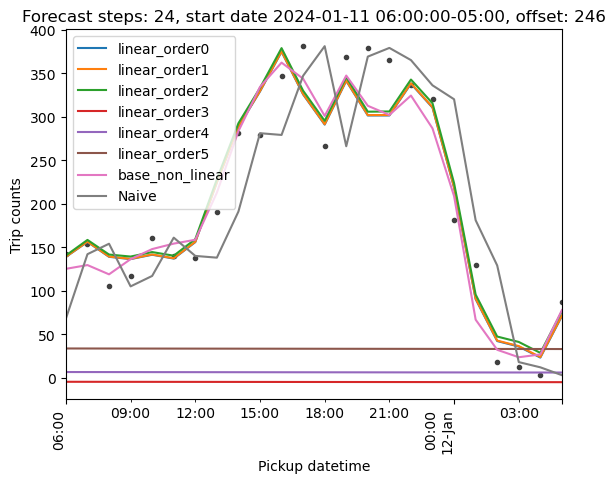

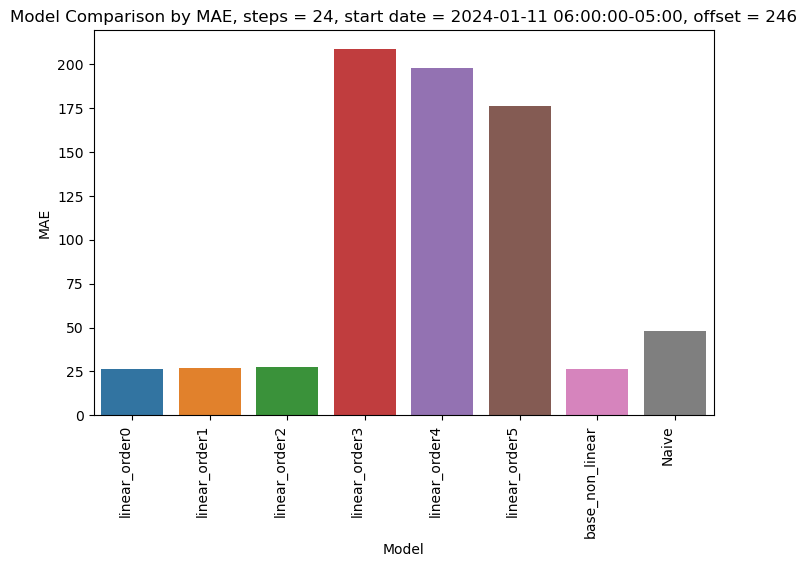

MAE: 31.84 for step = 168, model = linear_order0
MAE: 31.94 for step = 168, model = linear_order1
MAE: 33.77 for step = 168, model = linear_order2
MAE: 213.29 for step = 168, model = linear_order3
MAE: 202.57 for step = 168, model = linear_order4
MAE: 178.68 for step = 168, model = linear_order5
MAE: 33.11 for step = 168, model = base_non_linear
MAE: 52.86 for step =  30, model = Naive



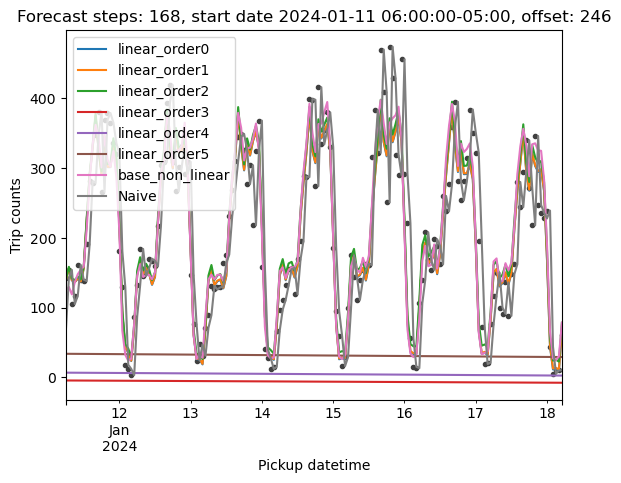

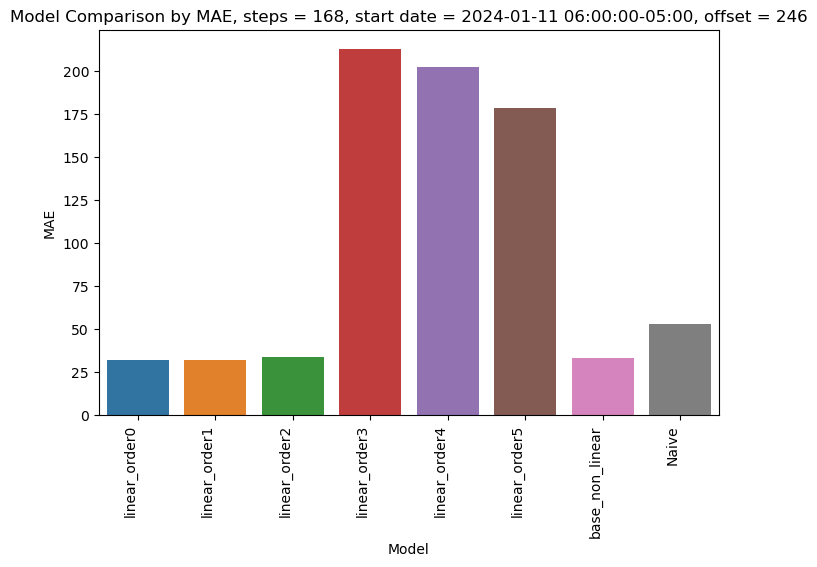

MAE: 30.04 for step = 720, model = linear_order0
MAE: 31.08 for step = 720, model = linear_order1
MAE: 45.39 for step = 720, model = linear_order2
MAE: 190.57 for step = 720, model = linear_order3
MAE: 181.36 for step = 720, model = linear_order4
MAE: 158.19 for step = 720, model = linear_order5
MAE: 45.32 for step = 720, model = base_non_linear
MAE: 46.96 for step =  30, model = Naive



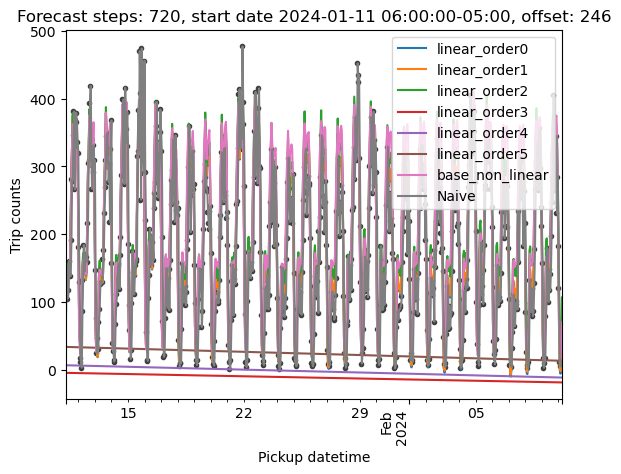

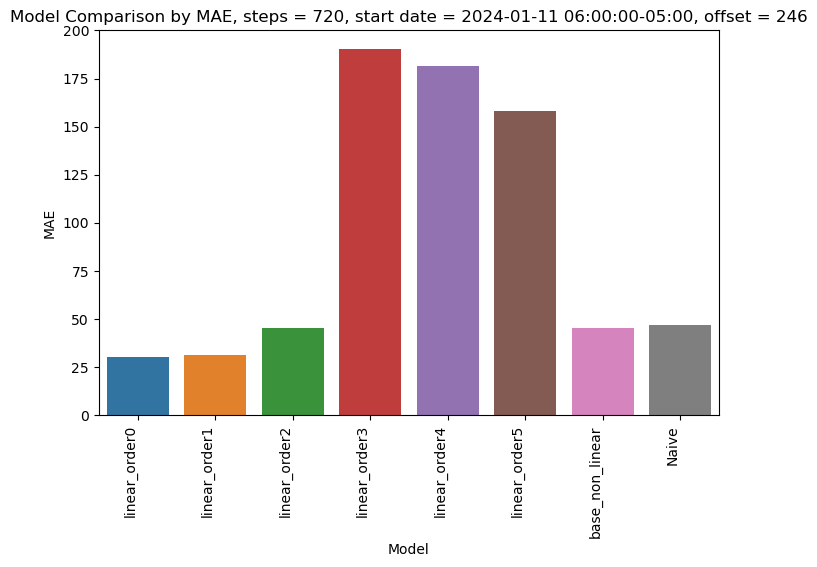


Average MAE scores for step 24:
linear_order0, average MAE: 31.37
linear_order3, average MAE: 348.82
linear_order2, average MAE: 32.40
linear_order1, average MAE: 31.43
linear_order4, average MAE: 386.24
linear_order5, average MAE: 397.11
base_non_linear, average MAE: 32.24
Naive, average MAE: 50.61

Average MAE scores for step 168:
linear_order0, average MAE: 34.72
linear_order3, average MAE: 358.37
linear_order2, average MAE: 36.41
linear_order1, average MAE: 34.75
linear_order4, average MAE: 396.48
linear_order5, average MAE: 407.83
base_non_linear, average MAE: 34.45
Naive, average MAE: 53.16

Average MAE scores for step 720:
linear_order0, average MAE: 38.49
linear_order3, average MAE: 367.91
linear_order2, average MAE: 45.23
linear_order1, average MAE: 38.37
linear_order4, average MAE: 408.75
linear_order5, average MAE: 422.37
base_non_linear, average MAE: 39.34
Naive, average MAE: 54.01


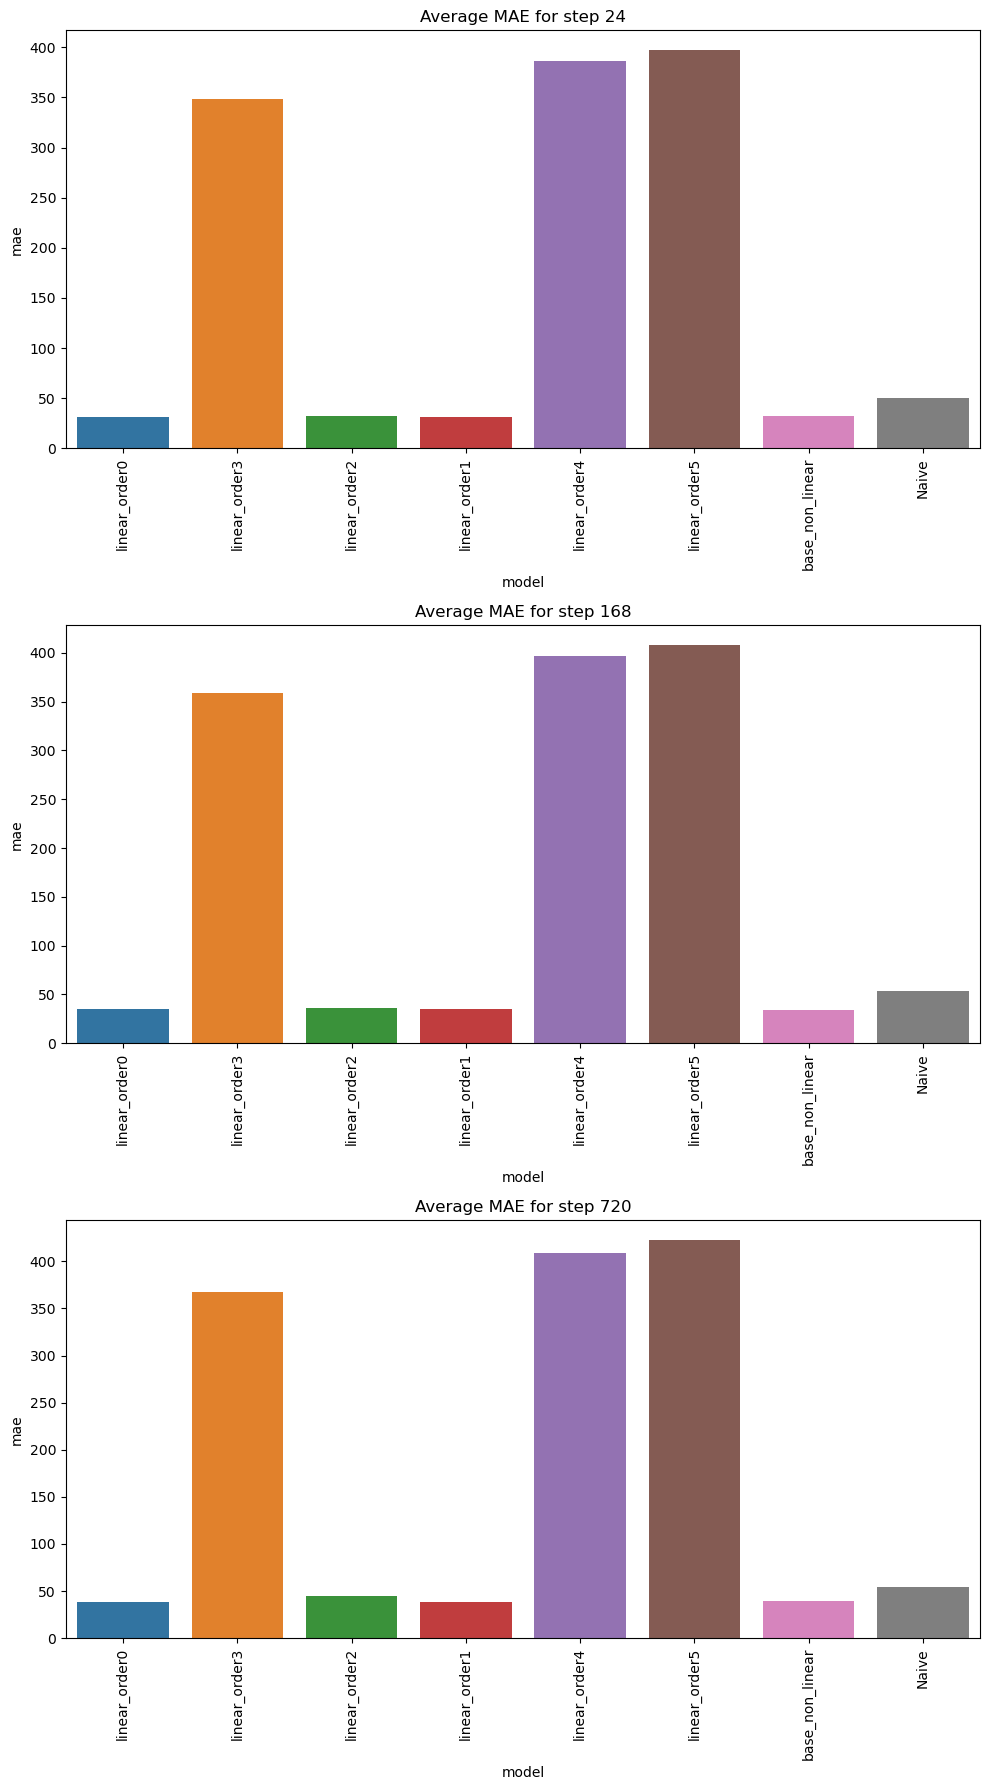

In [41]:
# Run forecasts
run_forecasts(steps, offset_list, offset_to_show, linear_models_loaded, non_linear_models_loaded, naive, time_step, ts_train, ts_test)

The first thing to note in the above that linear_order3, 4 and 5 seem to look rather strange with rather odd what look like mostly constant/straight line predictions. Again this is likely caused by the order of the polynomial being too large and so by the time we reach our forecasts the large values of the trend have caused the model to predict close to 0, whereas in the linear case for large polynomial trend orders it predicted very high. 

If we look at the 24 hour forecast we have that the lowest average MAE is linear_order0 at 31.37, followed by linder_order1 with 31.43 followed by base_non_linear with 32.24. Naive baseline has an average MAE of 50.61 so we are looking at a 38% improvement on baseline. Again it's also worth making some brief comments on the relative scale of hourly taxi pick ups at JFK Airport to put the MAE in context. If you refer to 2_data_processing from the hourly time series plots it seems that hourly taxis pick ups at JFK are between 0 and 600. However due to the fact the pick up count does fall to near 0 it is a bit difficult to give an easy worst case scenario for accuracy. Looking at the plots themselves it does appear that the models are following the general trend of the data which is reasuring. 

If we look at the 168 hour forecast (1 week) we see that the the lowest average MAE is base_non_linear at 34.45, followed by linear_order0 at 34.72 and then linear_order1 at 34.75. Naive baseline has an average MAE of 53.16 so we are looking at a 35.2% improvement on baseline.

Looking at the 720 hour forecast (1 month) we see that the lowest average MAE is linear_order1 at 38.37, followed by linear_order0 at 38.49 and then base_non_linear at 39.34. Naive baseline has an average MAE of 54.01 so we are looking at a 29.0% improvement on baseline.

Again it is interesting to note that the three best models seem to be linear_order0, linear_order1 and base_non_linear who all perform fairly similar to each other. Linear_order2 does perform noticeably worse with a 45.23 average MAE on the 720 forecast, suggesting that clearly a quadratic trend does not fit the hourly forecast as well as it perhaps does with a daily one.

Now we are going to do the same with hybrid models for the hourly time series.

In [42]:
# Create models and forecasts for daily ts

# 181 days in 2025 in the data, meaning 546 is the max number of steps we can forecast

# Steps for the forecast (read config.yml to see and change the steps for the forecast)
steps = config["modelling"]["hourly_steps"]

# Offset
offset_list = config["modelling"]["hourly_offset"]

# List of offsets to show the forecasts for
offset_to_show = config["modelling"]["hourly_offsets_to_show"]

# Fourier features (weekly and daily)
fourier_features = config["modelling"]["hourly_fourier_features"]

# List of trend orders for our linear models 
order_list = config["modelling"]["hourly_hybrid_trends"]

# Hybrid, the hybrid model we will be using
hybrid = XGBRegressor(
        n_estimators=config["xgboost_default"]["n_estimators"],
        learning_rate=config["xgboost_default"]["learning_rate"],
        max_depth=config["xgboost_default"]["max_depth"],
        subsample=config["xgboost_default"]["subsample"],
        colsample_bytree=config["xgboost_default"]["colsample_bytree"],
        random_state=config["xgboost_setup"]["random_state"],
        eval_metric=config["xgboost_setup"]["eval_metric"],
        tree_method=config["xgboost_setup"]["tree_method"],
        device=config["xgboost_setup"]["device"]
)

# Time step of the series
time_step = "h"

# Time series to use for training
ts_train = ts_hourly_train

# Time series to use for testing
ts_test = ts_hourly_test

# Lags for training
lags = used_hourly_lags

# Hybrid name list (list of names for the hybrid models)
names_hybrid = [f"{config['model_naming']['hybrid_model_prefix']}{i}" for i in order_list]

# Non linear name list 
names_non_linear = [config["model_naming"]["default_non_linear"]]

# Signature for the file names (this will be how we keep track of which files belong to which models when it comes to hyperparamter tuning)
sig = config["model_sigs"]["hourly_hybrid"]

# Naive baseline (bool to determine whether or not to inlcude a naive baseline in the plots, the naive baseline will just predict time step value t as time step value t-1)
naive = True

In [43]:
# Create train and save the models
create_train_save_models(names_hybrid, names_non_linear, hybrid, sig, order_list, lags, fourier_features, time_step, ts_train)

In [44]:
# Load the models (and the deterministic processes)
hybrid_models_loaded, non_linear_models_loaded = load_models(sig)

MAE: 27.49 for step = 24, model = hybrid_order0
MAE: 26.72 for step = 24, model = hybrid_order1
MAE: 27.69 for step = 24, model = hybrid_order2
MAE: 61.34 for step = 24, model = hybrid_order3
MAE: 26.42 for step = 24, model = base_non_linear
MAE: 47.88 for step =  30, model = Naive



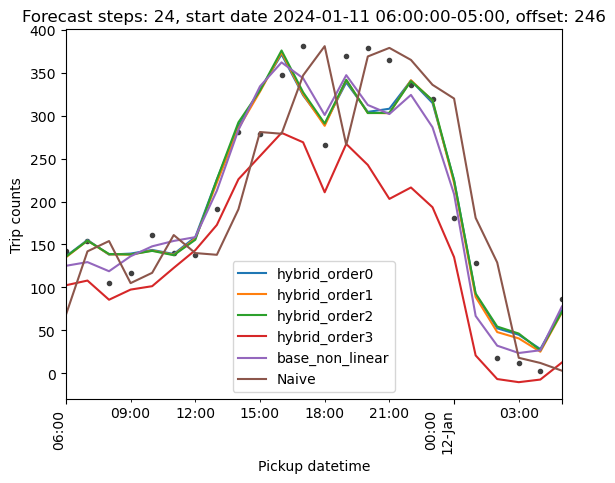

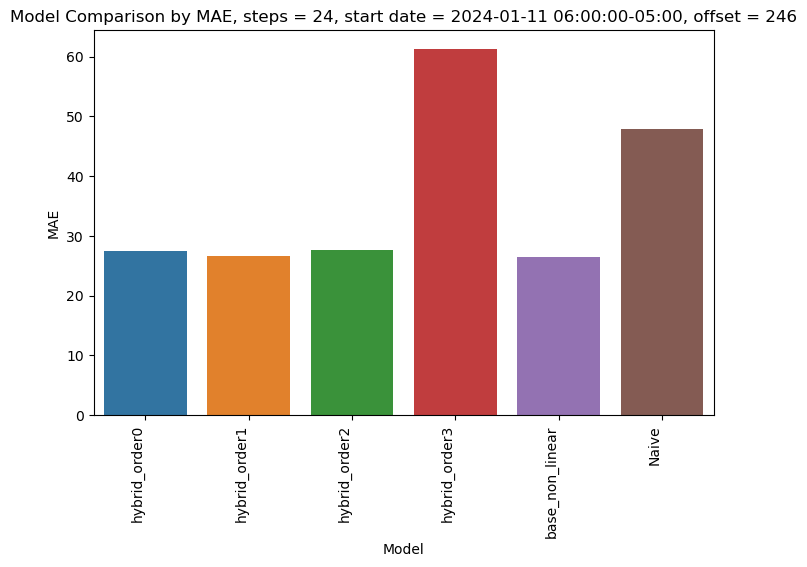

MAE: 33.12 for step = 168, model = hybrid_order0
MAE: 32.67 for step = 168, model = hybrid_order1
MAE: 33.18 for step = 168, model = hybrid_order2
MAE: 85.89 for step = 168, model = hybrid_order3
MAE: 33.11 for step = 168, model = base_non_linear
MAE: 52.86 for step =  30, model = Naive



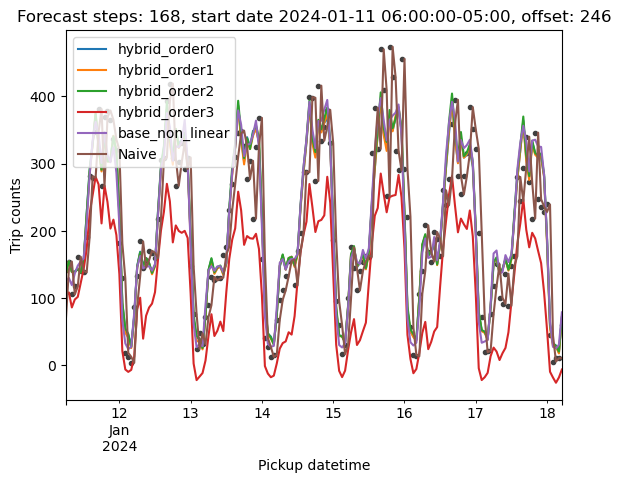

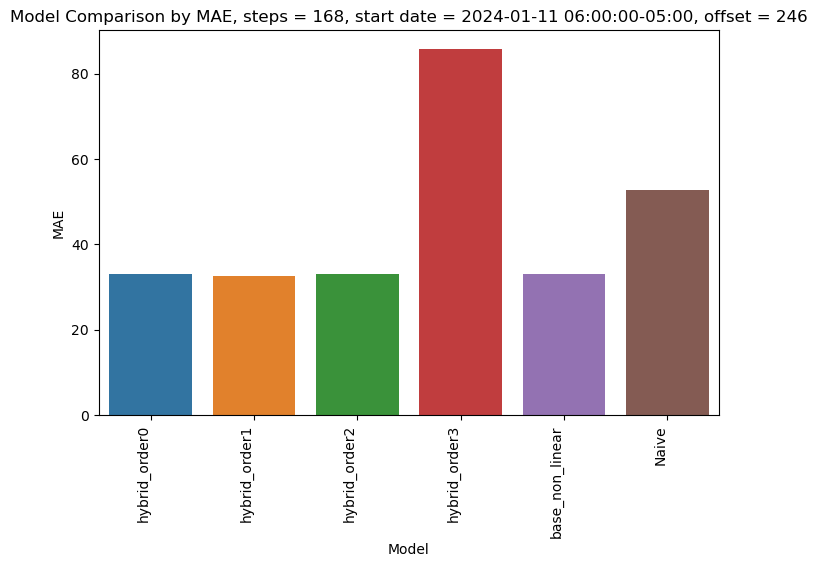

MAE: 43.97 for step = 720, model = hybrid_order0
MAE: 42.70 for step = 720, model = hybrid_order1
MAE: 43.68 for step = 720, model = hybrid_order2
MAE: 96.15 for step = 720, model = hybrid_order3
MAE: 45.32 for step = 720, model = base_non_linear
MAE: 46.96 for step =  30, model = Naive



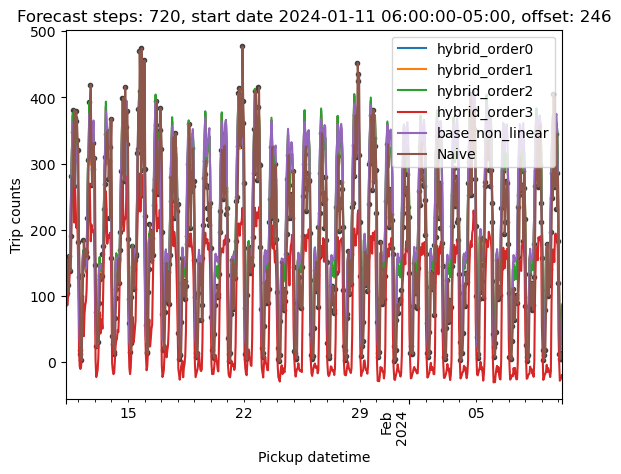

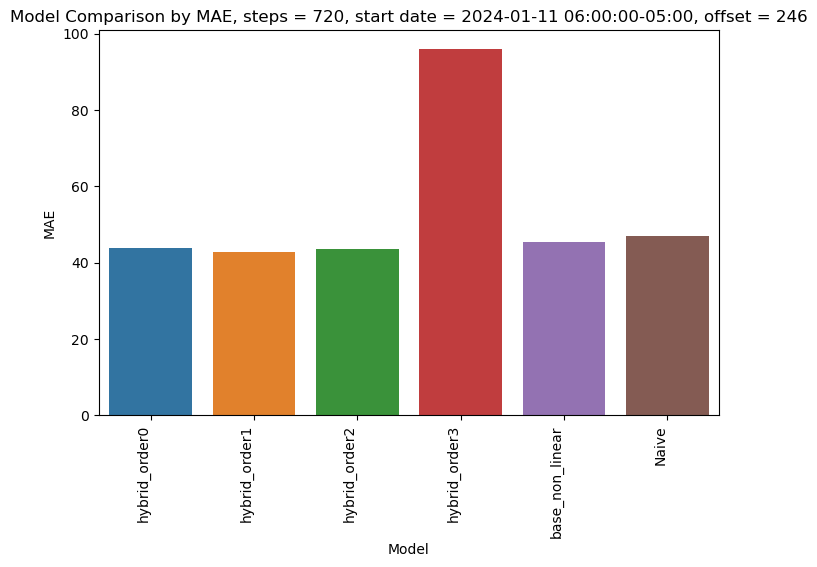


Average MAE scores for step 24:
hybrid_order2, average MAE: 31.62
hybrid_order1, average MAE: 31.29
hybrid_order0, average MAE: 31.04
base_non_linear, average MAE: 32.24
hybrid_order3, average MAE: 300.60
Naive, average MAE: 50.61

Average MAE scores for step 168:
hybrid_order2, average MAE: 34.57
hybrid_order1, average MAE: 34.26
hybrid_order0, average MAE: 34.18
base_non_linear, average MAE: 34.45
hybrid_order3, average MAE: 340.89
Naive, average MAE: 53.16

Average MAE scores for step 720:
hybrid_order2, average MAE: 39.28
hybrid_order1, average MAE: 38.66
hybrid_order0, average MAE: 38.64
base_non_linear, average MAE: 39.34
hybrid_order3, average MAE: 351.50
Naive, average MAE: 54.01


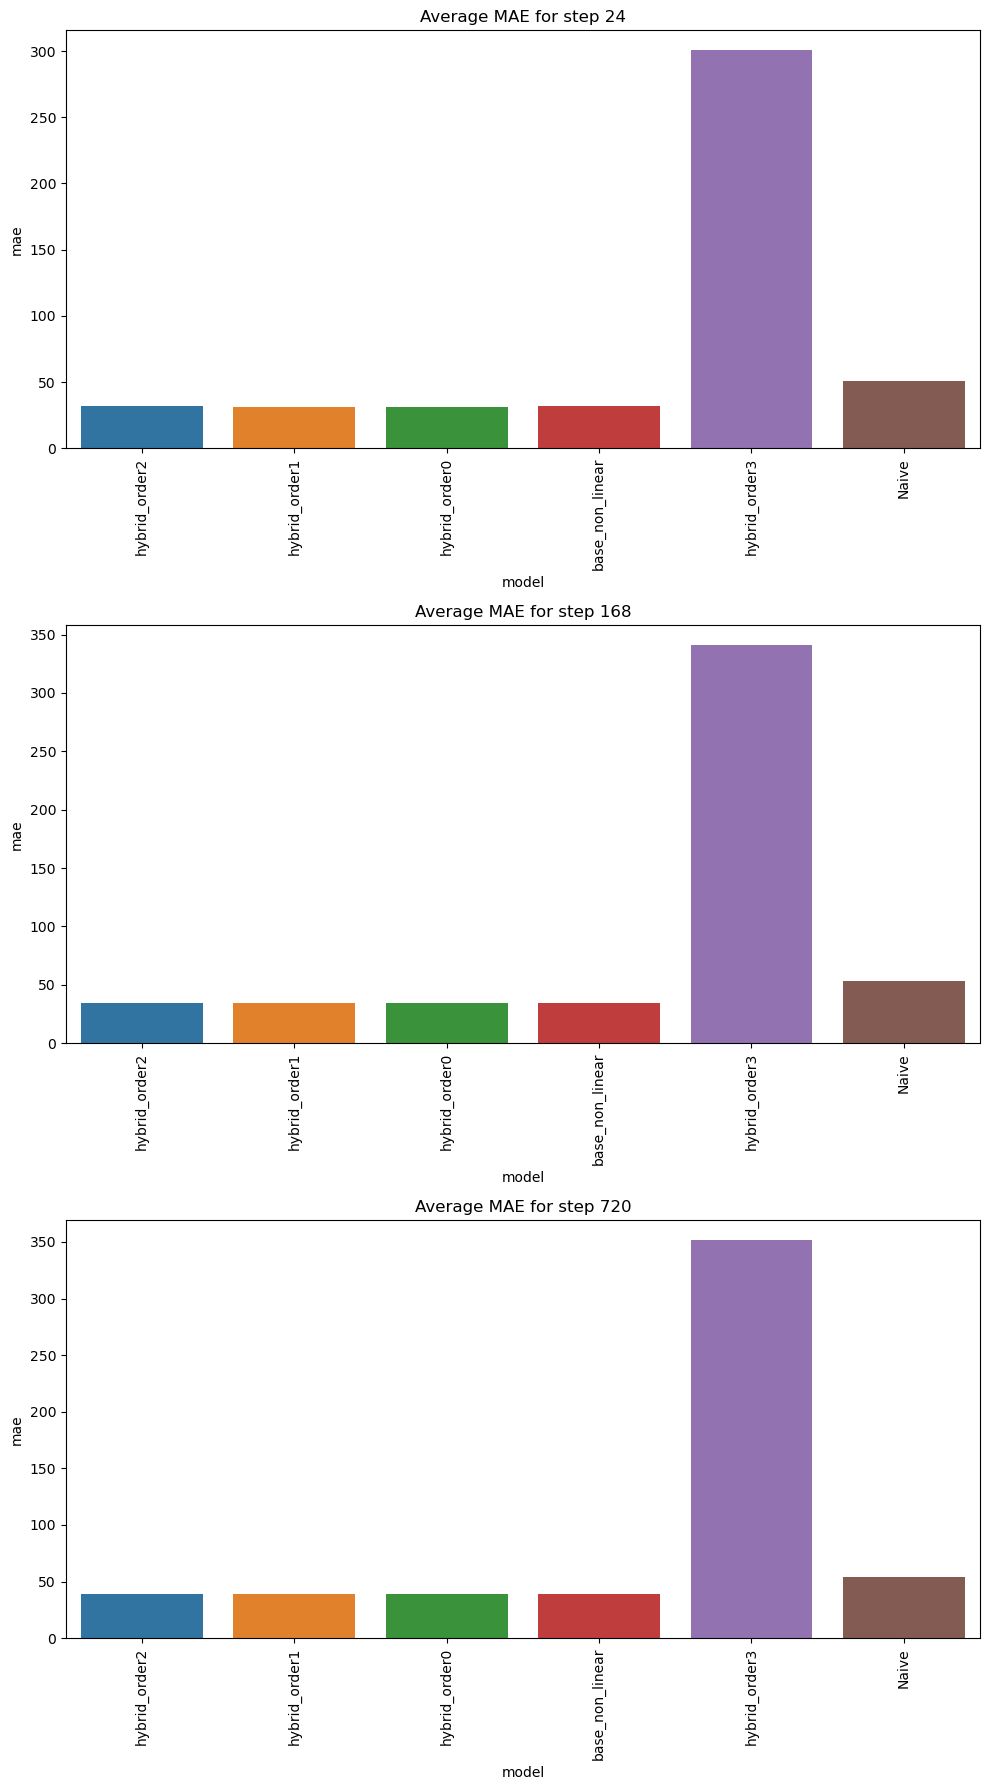

In [45]:
# Run forecasts
run_forecasts(steps, offset_list, offset_to_show, hybrid_models_loaded, non_linear_models_loaded, naive, time_step, ts_train, ts_test)

Again we see that hybrid_order3 very clearly isn't fitting to the data properly and appears to be consitently predicting too low, although clearly having xgboost fitted to the residuals has caused a considerable improvement to the model. Just not enough to make it competitive with the others but that is what we would expect as linear_order3 appears to be a rather poor model for the data. 

For the 24 hour forecast we have that hybrid_order0 has the lowest average MAE at 31.04, followed by hybrid_order1 at 31.29 and then hybrid_order2 at 31.62. Naive baseline has an average MAE of 50.61. So we are looking at a 38.7% improvement on baseline. Now this is actually a very tiny improvement (about 0.33 MAE) compared to the linear case, as linear_order0 had the lowest average MAE at 31.37. This could potentially be improved with hyperparameter tuning on the xgboost component of the linear model.

For the 168 hour (1 week) forecast we have that hybrid_order0 has the lowest average MAE at 34.18, followed by hybrid_order1 at 34.26 and then base_non_linear at 34.45. Naive baseline has an average MAE of 53.16 so we are looking at a 35.7% improvement on baseline. Again this is a very slight improvement on the purely linear case where the model with the lowest average MAE was base_non_linear so we have reduced the average MAE across the offsets by 0.27. 

For the 720 hour (1 month) forecast we have that hybrid_order0 has the lowest average MAE at 38.64, followed by hybrid_order1 at 38.66 and then hybrid_order2 at 39.28. Naive baseline has an average MAE of 54.01 so we are looking at a 28.5% improvement on baseline. This is actually slightly worse than the purely linear case where the lowest average MAE was linear_order1 at 38.37, so a difference of just 0.27 with hybrid_order0.

Some comments on the above, the first is that it is interesting that in the hourly case the hybrid models general perform slightly better than the purely linear ones (although not for the 1 month forecast). This is likely because on an hourly scale having xgboost be able to help with that slightly more random walk looking data will be more useful to the models, that in the daily case. Now it is also interesting that the best hybrid model is hybrid_order0 across all forecasts. That again points to the fact that it seems in the hourly case the trend is much less useful than the daily. Likely because on hourly basis taxi pick ups probably don't look terribly different in 2025 than they did in 2011. In fact if you look at 2_data_processing you can see two time series plots, one for the hourly taxi pick ups in January 2011 at JFK Airport and one for January 2025, and although the 2025 hourly taxi pick ups are slightly lower in terms of scale the two plots do look fairly similar. 

We will briefly conclude our current findings here before moving onto the final notebook 5_model_selection. The idea now is we want to try two things, the first is to see if we can find a reduced feature set that captures most of the signal. This is largely because we have a large number of lags and likely some of these lags aren't providing that much input to the models when it comes to predictions. Particularly for xgboost this could be a very useful thing to do as xgboost has to randomly sample the columns when choosing features for each tree in the model, and so removing any features that don't provide much signal will potentially improve the model. It will also make training noteably faster which will be very helpful when it comes to the second task we would like to perform, hyperparameter tuning. We are going to perform Bayesian hyperparameter tuning to see if we can improve our base_non_linear model (xgboost) as well as the hybrid model, especially as in both the hourly and daily case the hybrid and pure linear models are very close it would be interesting to see whether with some hyperparameter tuning can tip the balance in favour of the hybrid models. 

Below we list the model with the lowest average MAE across all the offsets for the forecast step and its percentage improvement on the naive baseline.<br>
<br>
Daily time series:<br>
<br>
7 day forecast best model: base_non_linear<br>
Average MAE across the offsets: 394.24<br>
Percentage improvement on naive baseline: 34.5%<br>
<br>
30 day forecast best model: linear_order2<br>
Average MAE across the offsets: 415.41<br>
Percentage improvement on naive baseline: 34.1%<br>
<br>
60 day forecast best model: linear_order2<br>
Average MAE across the offsets: 470.28<br>
Percentage improvement on naive baseline: 34.1%<br>
<br>
<br>
Hourly time series:<br>
<br>
24 hour forecast best model: hybrid_order0<br>
Average MAE across the offsets: 31.04<br>
Percentage improvement on naive baseline: 38.7%<br>
<br>
168 hour forecast best model: hybrid_order0<br>
Average MAE across the offsets: 34.18<br>
Percentage improvement on naive baseline: 35.7%<br>
<br>
720 hour forecast best model: hybrid_order0<br>
Average MAE across the offsets: 38.64<br>
Percentage improvement on naive baseline: 28.5%<br>